In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importing 'applications.csv' dataset from Google Drive:
#https://drive.google.com/file/d/1d31Vnr95biXHP8Ovkrk8UgjhVJlRQ5Du/view?usp=sharing

file_id = "1d31Vnr95biXHP8Ovkrk8UgjhVJlRQ5Du"
url = f"https://drive.google.com/uc?id={file_id}"

applications = pd.read_csv(url)
#Make a copy of original dataset for work
applications_copy = applications.copy()
#Checking first 5 rows
applications_copy.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [ ]:
#Checking size of dataset
print(f"Dataset 'applications.csv' size: {applications_copy.shape}")
print("="*50)
#Checking columns info and types
print(applications_copy.info())

Dataset 'applications.csv' size: (13315, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13315 entries, 0 to 13314
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Applied at       13315 non-null  object 
 1   Amount           13272 non-null  float64
 2   Age              13315 non-null  int64  
 3   Gender           13315 non-null  object 
 4   Industry         13315 non-null  object 
 5   Marital status   13315 non-null  object 
 6   External Rating  13243 non-null  float64
 7   Education level  13282 non-null  object 
 8   Location         11540 non-null  object 
 9   applicant_id     13315 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.0+ MB
None


In [ ]:
applications_copy['Date_Part'] = applications_copy['Applied at'].str.split(' ').str[0]

#Отримання унікальних значень дати у вигляді рядків
unique_dates = applications_copy['Date_Part'].unique()

#Виведення кількості та списку унікальних дат
num_unique_dates = len(unique_dates)

print(f"Загальна кількість унікальних дат (без часу): {num_unique_dates}\n")
print("Усі унікальні значення дат:")
print(unique_dates.tolist())

Загальна кількість унікальних дат (без часу): 41

Усі унікальні значення дат:
['11.30.2022', '12.01.2022', '12.02.2022', '12.03.2022', '12.04.2022', '12.05.2022', '12.06.2022', '12.07.2022', '12.08.2022', '12.09.2022', '12.10.2022', '12.11.2022', '12.12.2022', '12.13.2022', '12.14.2022', '12.15.2022', '12.16.2022', '12.17.2022', '12.18.2022', '12.19.2022', '12.20.2022', '12.21.2022', '12.22.2022', '12.23.2022', '12.24.2022', '12.25.2022', '12.26.2022', '12.27.2022', '12.28.2022', '12.29.2022', '12.30.2022', '12.31.2022', '01.01.2023', '01.02.2023', '01.03.2023', '01.04.2023', '01.05.2023', '01.06.2023', '01.07.2023', '01.08.2023', '01.09.2023']


In [ ]:
#Formatting 'Applied at' to right format
applications_copy['Applied at'] = pd.to_datetime(applications_copy['Applied at'], format='mixed', errors='coerce')
#Checking types
applications_copy.info()
#Checking first 5 rows
applications_copy.head()
#Checking NaT values after convertation
print(f"Number of NaT values in data column: {applications_copy['Applied at'].isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13315 entries, 0 to 13314
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Applied at       13315 non-null  datetime64[ns]
 1   Amount           13272 non-null  float64       
 2   Age              13315 non-null  int64         
 3   Gender           13315 non-null  object        
 4   Industry         13315 non-null  object        
 5   Marital status   13315 non-null  object        
 6   External Rating  13243 non-null  float64       
 7   Education level  13282 non-null  object        
 8   Location         11540 non-null  object        
 9   applicant_id     13315 non-null  object        
 10  Date_Part        13315 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 1.1+ MB
Number of NaT values in data column: 0


In [ ]:
#Drop duplicates from 'applicant_id'
num_duplicates = applications_copy.duplicated(subset = ['applicant_id']).sum()
applications_copy = applications_copy.drop_duplicates(subset = ['applicant_id'], keep='first')
print(f"Number of duplicates in 'applicant_id' {num_duplicates}")
print(f"Dataset size (rows) before dropping: {applications.shape[0]}")
print(f"Dataset size (rows) after dropping: {applications_copy.shape[0]}")

Number of duplicates in 'applicant_id' 37
Dataset size (rows) before dropping: 13315
Dataset size (rows) after dropping: 13278


In [ ]:
#Filling missing values in 'External Rating' with 0
null_number = applications_copy['External Rating'].isnull().sum()
print(f"Number of missing values in 'External Rating' before filling with 0: {null_number}")
#checking 'External Rating' values
print("="*50)
print(applications_copy['External Rating'].value_counts())
applications_copy['External Rating'].fillna(0, inplace = True)
#checking 'External Rating' values again to ensure filling missing values (452 + 72 = 524 values in "0.0")
print("="*50)
print(applications_copy['External Rating'].value_counts())
#checking missing values after filling
print("="*50)
null_number = applications_copy['External Rating'].isnull().sum()
print(f"Number of missing values in 'External Rating' after filling with 0: {null_number}")

Number of missing values in 'External Rating' before filling with 0: 72
External Rating
3.0     2185
1.0     1964
4.0     1438
2.0     1416
5.0     1337
6.0      976
7.0      783
10.0     593
15.0     581
8.0      524
0.0      452
9.0      331
11.0     231
12.0     204
13.0      96
14.0      95
Name: count, dtype: int64
External Rating
3.0     2185
1.0     1964
4.0     1438
2.0     1416
5.0     1337
6.0      976
7.0      783
10.0     593
15.0     581
0.0      524
8.0      524
9.0      331
11.0     231
12.0     204
13.0      96
14.0      95
Name: count, dtype: int64
Number of missing values in 'External Rating' after filling with 0: 0


/tmp/ipython-input-2308647865.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applications_copy['External Rating'].fillna(0, inplace = True)


In [ ]:
#Filling missing values in 'Education level' with “Середня”
null_number = applications_copy['Education level'].isnull().sum()
print(f"Number of missing values in 'Education level' before filling: {null_number}")
#checking 'Education level' values
print("="*50)
print(applications_copy['Education level'].value_counts())
applications_copy['Education level'].fillna("Середня", inplace = True)
#checking 'Education level' values again to ensure filling missing values (444 + 33 = 477 values in "Середня")
print("="*50)
print(applications_copy['Education level'].value_counts())
#checking missing values after filling
print("="*50)
null_number = applications_copy['Education level'].isnull().sum()
print(f"Number of missing values in 'Education level' after filling with “Середня”: {null_number}")

Number of missing values in 'Education level' before filling: 33
Education level
Вища (бакалавр, спеціаліст, магістр)    10594
Дві вищі                                  994
Ще студент вишу                           806
Середня                                   444
Середня спеціальна                        407
Name: count, dtype: int64
Education level
Вища (бакалавр, спеціаліст, магістр)    10594
Дві вищі                                  994
Ще студент вишу                           806
Середня                                   477
Середня спеціальна                        407
Name: count, dtype: int64
Number of missing values in 'Education level' after filling with “Середня”: 0


/tmp/ipython-input-171855046.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applications_copy['Education level'].fillna("Середня", inplace = True)


In [ ]:
#Import 'industries.csv' from Google Drive
#https://drive.google.com/file/d/1WW35PRzA-ILpLDpoQFWAiOuf9pCB-VEk/view?usp=sharing

file_id = "1WW35PRzA-ILpLDpoQFWAiOuf9pCB-VEk"
url = f"https://drive.google.com/uc?id={file_id}"

industries = pd.read_csv(url)
#Make a copy of original dataset for work
industries_copy = industries.copy()
#Checking first 5 rows
industries_copy.head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


In [ ]:
#Add 'Score' to applications dataframe from industries
df_union = pd.merge(left = applications_copy,
                    right = industries_copy,
                    on = 'Industry',
                    how = 'left')
#checking first 5 rows of union dataset
print(df_union.head())
print(f"Number of rows of the union dataset: {df_union.shape[0]}")
null_number = df_union['Score'].isnull().sum()
#checking if there are missing values in merge column
print(f"Number of missing values in 'Score': {null_number}")

           Applied at   Amount  Age   Gender                      Industry  \
0 2022-11-30 10:26:37  12000.0   29  Чоловік                    Blockchain   
1 2022-11-30 10:26:39      NaN   36  Чоловік  Public services / Government   
2 2022-11-30 10:26:58   7500.0   34  Чоловік          Adtech / Advertising   
3 2022-11-30 10:27:31   1500.0   23    Жінка                       Telecom   
4 2022-11-30 10:27:34   8400.0   33    Жінка                    Automotive   

  Marital status  External Rating                       Education level  \
0          Other              8.0  Вища (бакалавр, спеціаліст, магістр)   
1         Single              3.0  Вища (бакалавр, спеціаліст, магістр)   
2         Single              4.0  Вища (бакалавр, спеціаліст, магістр)   
3         Single              0.0  Вища (бакалавр, спеціаліст, магістр)   
4         Single              6.0  Вища (бакалавр, спеціаліст, магістр)   

                      Location                      applicant_id   Date_Part  \


In [ ]:
#Create a column to calculate rating without restrictions
df_union['base_score'] = 0

#Якщо вік заявника між 35 та 55, до рейтингу додається 20 балів
age_mask = (df_union['Age'] >= 35) & (df_union['Age'] <=55)
df_union.loc[age_mask, 'base_score'] += 20
#Якщо заявка була подана не у вихідні, до рейтингу додається 20 балів
day_mask = df_union['Applied at'].dt.dayofweek < 5 # 0 - Monday, 1 - Tuesday, ..., 5 - Saturday, 6 - Sunday
df_union.loc[day_mask, 'base_score'] += 20
#Якщо заявник одружений, до рейтингу додається 20 балів
is_married_mask = df_union['Marital status'] == 'Married'
df_union.loc[is_married_mask, 'base_score'] += 20
#Якщо заявник знаходиться в Києві чи області, до рейтингу додається 10 балів
geo_loc_mask = df_union['Location'] == 'Київ чи область'
df_union.loc[geo_loc_mask, 'base_score'] += 10
#Значення 'Score' з таблиці industries.csv також додається до заявки (і складає від 0 до 20 балів)
df_union['base_score'] += df_union['Score']
#Якщо 'External Rating' більше чи дорівнює 7, до рейтингу додається 20 балів
er_mask_p = df_union['External Rating'] >= 7
df_union.loc[er_mask_p, 'base_score'] += 20
#Якщо 'External Rating' менше чи дорівнює 2, з рейтингу віднімається 20 балів
er_mask_m = df_union['External Rating'] <= 2
df_union.loc[er_mask_m, 'base_score'] -= 20
#checking result
df_union.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Date_Part,Score,base_score
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,11.30.2022,0,40
1,2022-11-30 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f,11.30.2022,20,60
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,11.30.2022,10,40
3,2022-11-30 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1,11.30.2022,15,15
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,11.30.2022,15,35


In [ ]:
#Set restrictions according to task
#Create column 'Application Rating' to apply restrictions
df_union['Application Rating'] = 0

#Рейтинг дорівнює нулю, якщо відсутнє значення 'Amount' або якщо 'External Rating' дорівнює нулю.
#Рейтинг має бути числом від 0 до 100
zero_mask = (df_union['Amount'].isnull()) | (df_union['External Rating'] == 0)
df_union['Application Rating'] = np.clip(np.where(zero_mask, 0, df_union['base_score']),
                                         a_min = 0,
                                         a_max = 100)
#checking if 'Application Rating' from 0 to 100
check_mask = (df_union['Application Rating'] < 0) & (df_union['Application Rating'] > 100)
print(f"Number of values ​​outside the range 0 - 100: {df_union[check_mask].shape[0]}")

Number of values ​​outside the range 0 - 100: 0


In [ ]:
#У результуючій таблиці залиш лише заявки з рейтингом більше нуля, ці заявки вважатимуться прийнятими
before = df_union.shape[0]
result_table = df_union[df_union['Application Rating'] > 0].copy()
after = result_table.shape[0]
print(f"Number of accepted applications: {after}")
print(f"Number of applications with rating 0: {before - after}")

Number of accepted applications: 12558
Number of applications with rating 0: 720


In [ ]:
result_table['Applied at'].dt.date


,Applied at
0,2022-11-30
2,2022-11-30
4,2022-11-30
5,2022-11-30
6,2022-11-30
...,...
13273,2023-01-09
13274,2023-01-09
13275,2023-01-09
13276,2023-01-09


  year_week  Application Rating
0   2022_48           50.644753
1   2022_49           49.448831
2   2022_50           49.773463
3   2022_51           46.959146
4   2022_52           50.945467
5   2023_01           51.484615
6   2023_02           51.875000


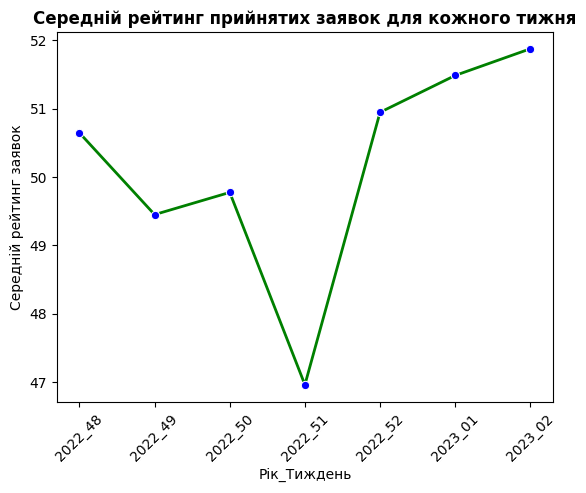

In [ ]:
#Застосовано групування за тижнем подачі заявки, і виведено таблицю середнього рейтингу прийнятих заявок для кожного тижня
#Calculate year, week
result_table['year'] = result_table['Applied at'].dt.isocalendar().year
result_table['week'] = result_table['Applied at'].dt.isocalendar().week
#form a field 'year_week'
result_table['year_week'] = result_table['year'].astype(str) + '_' + result_table['week'].astype(str).str.zfill(2)

average_rating_by_week = result_table.groupby('year_week')['Application Rating'].mean().reset_index()
print(average_rating_by_week)
#visualisation
sns.lineplot(average_rating_by_week,
             x='year_week',
             y='Application Rating',
             color = 'g',
             linewidth = 2,
             marker = 'o',
             markerfacecolor = 'b')
plt.title("Середній рейтинг прийнятих заявок для кожного тижня", fontweight = 'bold')
plt.xlabel("Рік_Тиждень")
plt.ylabel("Середній рейтинг заявок")
plt.xticks(rotation = 45)
plt.show()